In [54]:
# Robodesk
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
def plot_csv_files(directory_path, taskname, column_name=['x', 'y1', 'y2', 'y3']):
    files = os.listdir(directory_path)
    fig_width = 6.4
    fig_height = 4.8
    scale = 1.3
    plt.figure(figsize=(fig_width * scale, fig_height * scale))
    for file in files:
        if  file.endswith('.csv'):
            if not file.startswith('Interp'):
                file_path = os.path.join(directory_path, file)
                data = pd.read_csv(file_path, names=['x', 'y'])
                plt.plot(data['x'] * 1e6, data['y'], label=file[:-4], linewidth=2)
                # sns.lineplot(data=data, x='x', y='y', label=file[:-4], linewidth=3)
            else:
                file_path = os.path.join(directory_path, file)
                data = pd.read_csv(file_path, names=column_name)
                data['x'] = data['x']
                # print(data['x'][-1])
                mean = data[column_name[1:]].mean(axis=1)
                std = data[column_name[1:]].std(axis=1)
                plt.plot(data['x'], mean, label='IFactor (Ours)', linewidth=2)
                plt.fill_between(data['x'], mean - std, mean + std, alpha=0.2)
                
                # sns.lineplot(data=data, x='x', y='y', label="InterpRL", linewidth=3)
                
    fname = os.path.join(directory_path, f"{taskname}.pdf")
    plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    plt.title('Robodesk with Various Distractors', fontsize=24)
    plt.xlabel('Environment Steps', fontsize=22)
    plt.ylabel('Episode Return', fontsize=22)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(loc='upper left', fontsize=12)
    # plt.show()
    plt.savefig(fname)


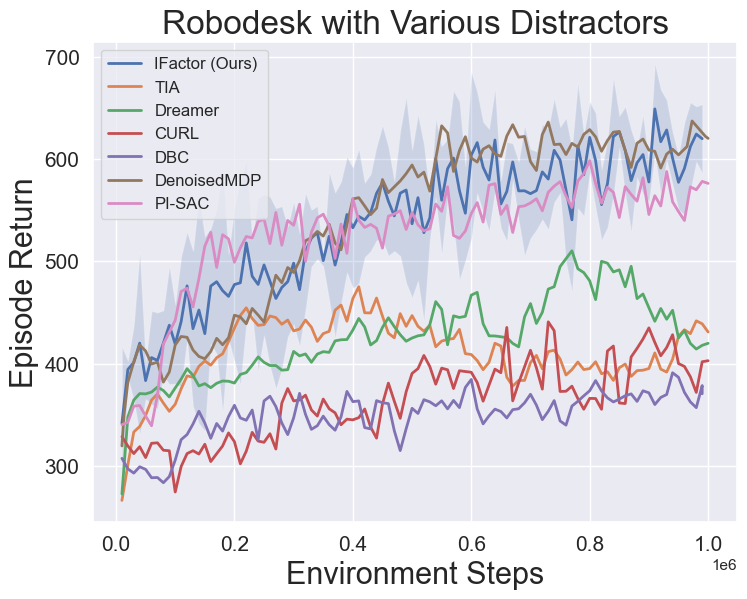

In [55]:

# Robodesk
directory_path = 'anonymized_path'
plot_csv_files(directory_path, column_name=['x', 'y1', 'y2', 'y3', 'y4', 'y5'], taskname='robodesk')

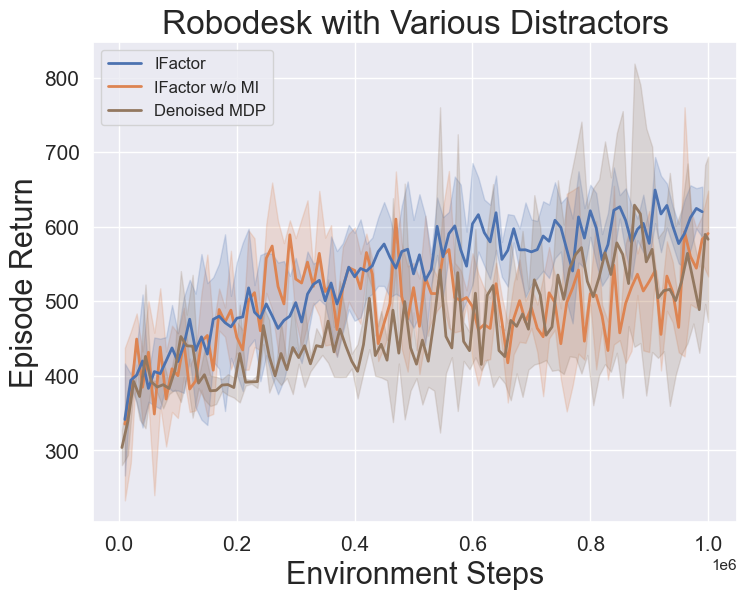

In [13]:
# Robodesk reproduction
# Robodesk
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
colors = sns.color_palette()

def plot_csv_files_reproduce(directory_path, taskname):
    files = os.listdir(directory_path)
    fig_width = 6.4
    fig_height = 4.8
    scale = 1.3
    plt.figure(figsize=(fig_width * scale, fig_height * scale))
    for file in files:
        if file == "IFactor.csv":
            file_path = os.path.join(directory_path, file)
            column_name = ['x', 'y1', 'y2', 'y3', 'y4', 'y5']
            data = pd.read_csv(file_path, names=column_name)
            data['x'] = data['x']
            # print(data['x'][-1])
            mean = data[column_name[1:]].mean(axis=1)
            std = data[column_name[1:]].std(axis=1)
            plt.plot(data['x'], mean, label='IFactor', linewidth=2, color=colors[0])
            plt.fill_between(data['x'], mean - std, mean + std, alpha=0.2, color=colors[0])
        if file == "IFactor_wo.csv":
            file_path = os.path.join(directory_path, file)
            column_name = ['x', 'y1', 'y2', 'y3']
            data = pd.read_csv(file_path, names=column_name)
            data['x'] = data['x']
            # print(data['x'][-1])
            mean = data[column_name[1:]].mean(axis=1)
            std = data[column_name[1:]].std(axis=1)
            plt.plot(data['x'], mean, label='IFactor w/o MI', linewidth=2, color=colors[1])
            plt.fill_between(data['x'], mean - std, mean + std, alpha=0.2, color=colors[1])
        if file == "Denoised.csv":
            file_path = os.path.join(directory_path, file)
            column_name = ['x', 'y1', 'y2', 'y3']
            data = pd.read_csv(file_path, names=column_name)
            data['x'] = data['x']
            # print(data['x'][-1])
            mean = data[column_name[1:]].mean(axis=1)
            std = data[column_name[1:]].std(axis=1)
            plt.plot(data['x'], mean, label='Denoised MDP', linewidth=2, color=colors[5])
            plt.fill_between(data['x'], mean - std, mean + std, alpha=0.2, color=colors[5])
                
                # sns.lineplot(data=data, x='x', y='y', label="InterpRL", linewidth=3)
                
    fname = os.path.join(directory_path, f"{taskname}.pdf")
    plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    plt.title('Robodesk with Various Distractors', fontsize=24)
    plt.xlabel('Environment Steps', fontsize=22)
    plt.ylabel('Episode Return', fontsize=22)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    handles, labels = plt.gca().get_legend_handles_labels()
    order = [1, 0, 2]
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left', fontsize=12)
    # plt.show()
    plt.savefig(fname)

plot_csv_files_reproduce("anonymized_path/robodesk_reproduce", taskname='robodesk_reproduce')


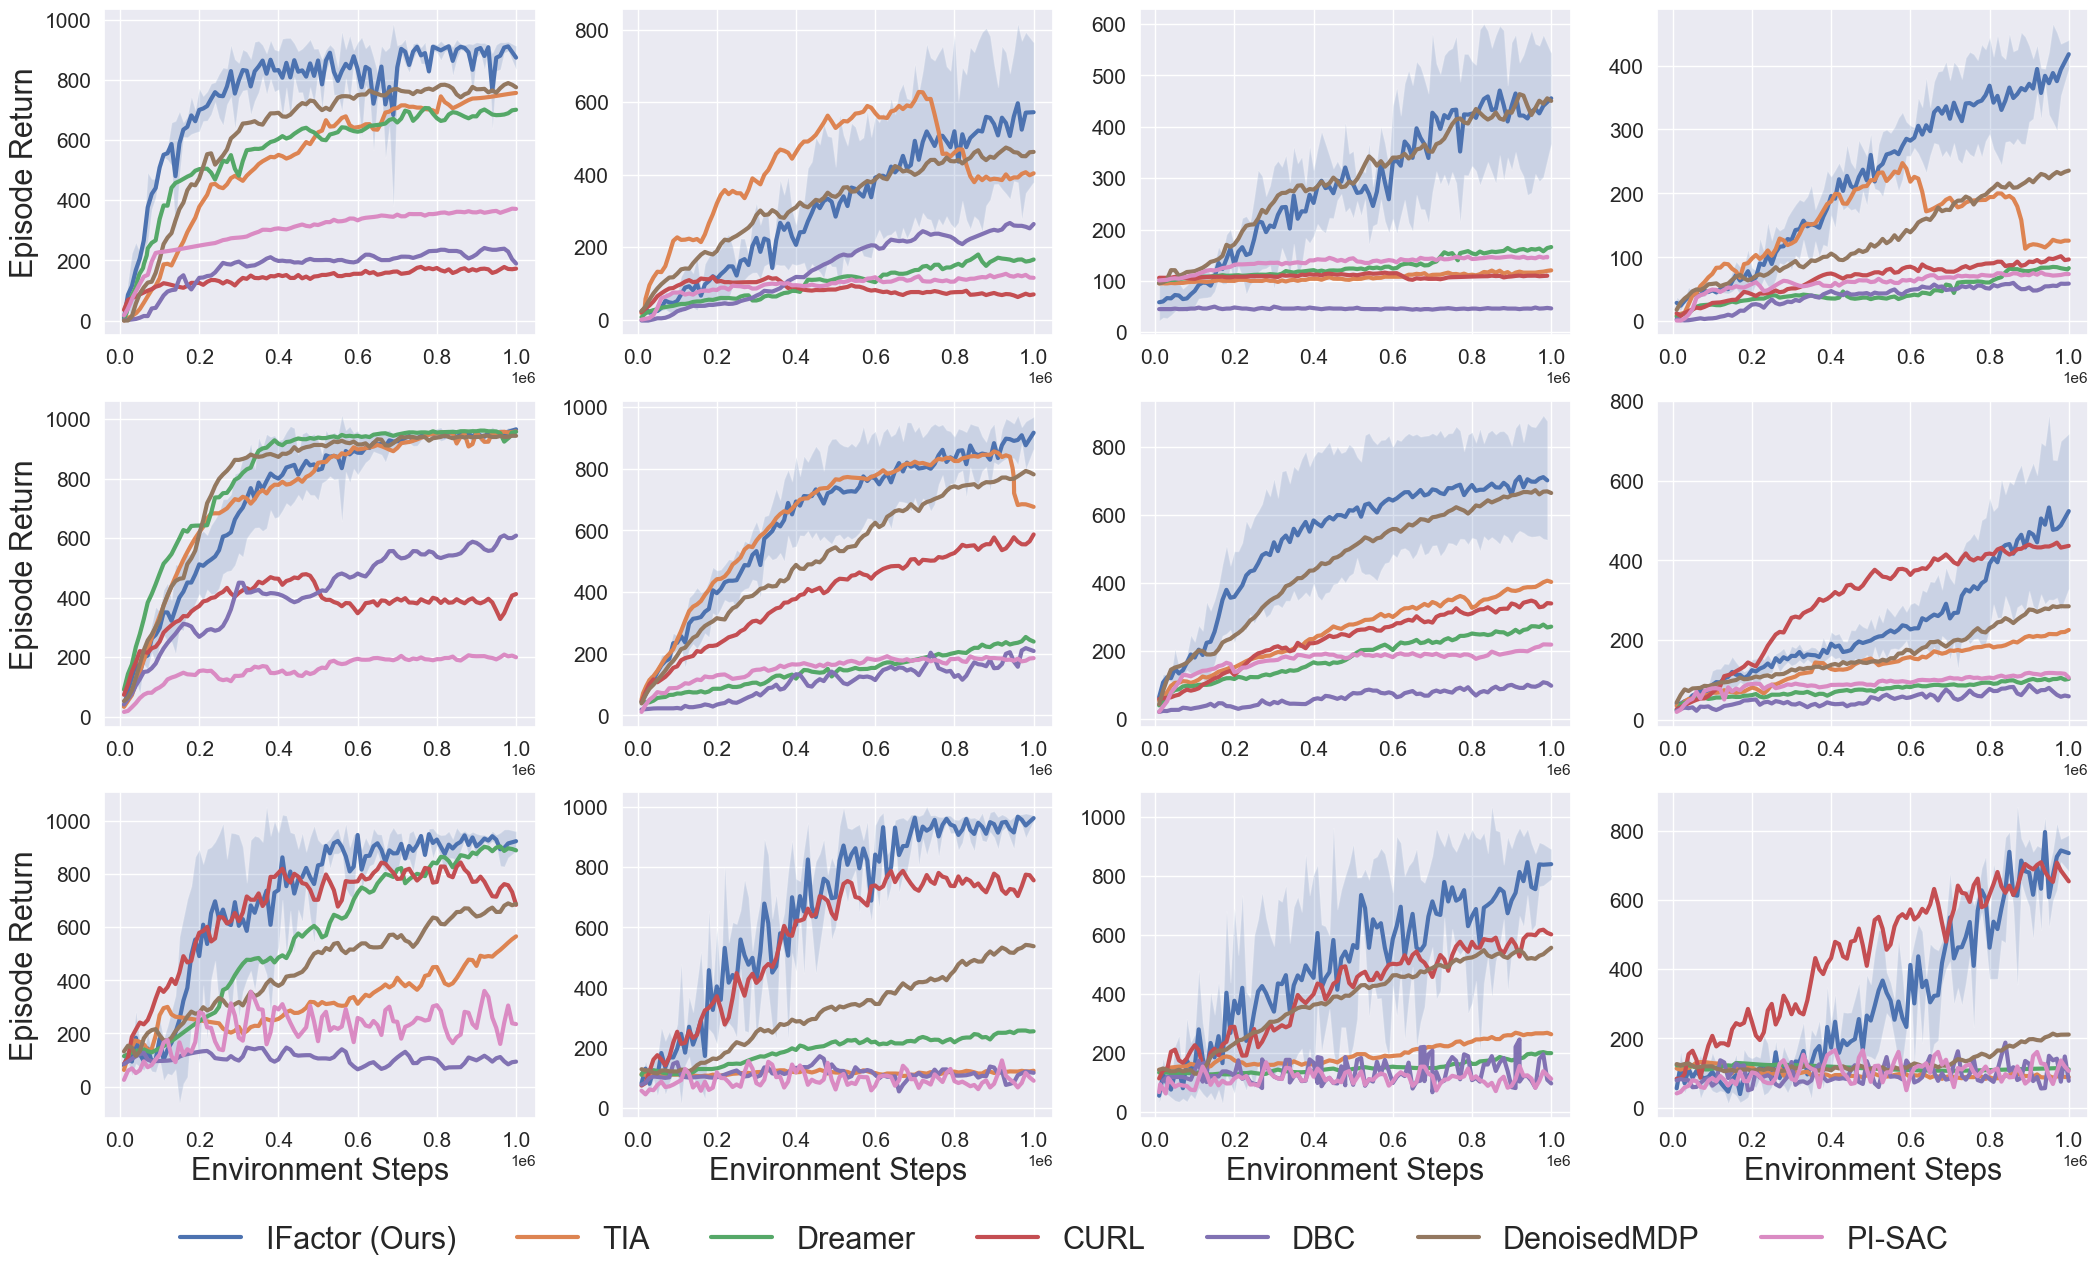

In [56]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
def plot_dmc(directory_path, ax, title, column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=True, set_ylabel=True, set_title=False):
    files = os.listdir(directory_path)

    for file in files:
        if  file.endswith('.csv'):
            if not file.startswith('Interp'):
                file_path = os.path.join(directory_path, file)
                data = pd.read_csv(file_path, names=['x', 'y'])
                ax.plot(data['x'] * 1e6, data['y'], label=file[:-4], linewidth=3)
                # sns.lineplot(data=data, x='x', y='y', label=file[:-4], linewidth=3)
            else:
                file_path = os.path.join(directory_path, file)
                data = pd.read_csv(file_path, names=column_name)
                data['x'] = data['x']
                # print(data['x'][-1])
                mean = data[column_name[1:]].mean(axis=1)
                std = data[column_name[1:]].std(axis=1)
                ax.plot(data['x'], mean, label='IFactor (Ours)', linewidth=3)
                ax.fill_between(data['x'], mean - std, mean + std, alpha=0.2)
                
                # sns.lineplot(data=data, x='x', y='y', label="InterpRL", linewidth=3)
                
    # fname = os.path.join(directory_path, f"{taskname}.pdf")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    if set_title:
        ax.set_title(title, fontsize=14)
    if set_xlabel:
        ax.set_xlabel('Environment Steps', fontsize=22)
    if set_ylabel:
        ax.set_ylabel('Episode Return', fontsize=22)
    # plt.legend(title='File', loc='upper right')
    # plt.show()

fig,axes = plt.subplots(3,4, figsize=(25.6, 14.4),)
cheetah_noiseless_path = 'anonymized_path'
cheetah_video_path = 'anonymized_path'
cheetah_noisy_path = 'anonymized_path'
cheetah_jitter_path = 'anonymized_path'

walker_noiseless_path = 'anonymized_path'
walker_video_path = 'anonymized_path'
walker_noisy_path = 'anonymized_path'
walker_jitter_path = 'anonymized_path'

reacher_noiseless_path = 'anonymized_path'
reacher_video_path = 'anonymized_path'
reacher_noisy_path = 'anonymized_path'
reacher_jitter_path = 'anonymized_path'


plot_dmc(cheetah_noiseless_path, axes[0, 0], 'Cheetah', column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=False, set_ylabel=True)
plot_dmc(cheetah_video_path, axes[0, 1], 'Cheetah + Video Background', column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=False, set_ylabel=False)
plot_dmc(cheetah_noisy_path, axes[0, 2], 'Cheetah + Video Background + Noisy Sensor', column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=False, set_ylabel=False)
plot_dmc(cheetah_jitter_path, axes[0, 3], 'Cheetah + Video Background + Camera Jittering', column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=False, set_ylabel=False)

plot_dmc(walker_noiseless_path, axes[1, 0], 'Walker', column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=False, set_ylabel=True)
plot_dmc(walker_video_path, axes[1, 1], 'Walker + Video Background', column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=False, set_ylabel=False)
plot_dmc(walker_noisy_path, axes[1, 2], 'Walker + Video Background + Noisy Sensor', column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=False, set_ylabel=False)
plot_dmc(walker_jitter_path, axes[1, 3], 'Walker + Video Background + Camera Jittering', column_name=['x', 'y1', 'y2', 'y3'], set_xlabel=False, set_ylabel=False)

plot_dmc(reacher_noiseless_path, axes[2, 0], 'Reacher', column_name=['x', 'y1', 'y2', 'y3'], set_ylabel=True)
plot_dmc(reacher_video_path, axes[2, 1], 'Reacher + Video Background', column_name=['x', 'y1', 'y2', 'y3'], set_ylabel=False)
plot_dmc(reacher_noisy_path, axes[2, 2], 'Reacher + Video Background + Noisy Sensor', column_name=['x', 'y1', 'y2', 'y3'], set_ylabel=False)
plot_dmc(reacher_jitter_path, axes[2, 3], 'Reacher + Video Background + Camera Jittering', column_name=['x', 'y1', 'y2', 'y3'], set_ylabel=False)
# Create a shared legend
lines, labels = axes[2, 3].get_legend_handles_labels()
# for ax in axs[1:]:
#     line, label = ax.get_legend_handles_labels()
#     lines += line
#     labels += label
# fig.legend(lines, labels, loc='center right', bbox_to_anchor=(1.1, 0.5), fontsize=12)
legend = fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0.055), ncol=7, fontsize=22)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('none')
frame.set_linewidth(0)
# frame.set_edgecolor('white')legend.get_lines()[0].set_color('white')
# legend.get_patches()[0].set_facecolor('white')

# fig.subplots_adjust(bottom=0.2)
plt.savefig('anonymized_path/dmc.pdf', bbox_inches='tight')